In [213]:
import requests
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.decomposition import FastICA, NMF, KernelPCA, PCA
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import SpectralEmbedding
from sklearn.manifold import MDS
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
#run: pip install umap-learn 
from sklearn.metrics import pairwise_distances
import umap
from sklearn.cluster import SpectralBiclustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

In [2]:
print(umap.__file__)

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/__init__.py


In [3]:
url = 'https://raw.githubusercontent.com/DataSlingers/clustRviz/master/data/authors.rda'
resp = requests.get(url = url)

In [4]:
resp.status_code

200

In [5]:
type(resp)

requests.models.Response

In [6]:
with open('author.rda', 'wb') as file:
    file.write(resp.content)

In [7]:
data_raw = pyreadr.read_r('author.csv')

In [8]:
type(data_raw)

collections.OrderedDict

In [9]:
data_raw.keys()

odict_keys(['authors'])

In [10]:
data_raw.values()

odict_values([                a   all  also   an   and  any   are    as    at    be  ...  \
Austen       46.0  12.0   0.0  3.0  66.0  9.0   4.0  16.0  13.0  13.0  ...   
Austen       35.0  10.0   0.0  7.0  44.0  4.0   3.0  18.0  16.0   9.0  ...   
Austen       46.0   2.0   0.0  3.0  40.0  1.0  13.0  11.0   9.0  23.0  ...   
Austen       40.0   7.0   0.0  4.0  64.0  3.0   3.0  20.0  13.0  20.0  ...   
Austen       29.0   5.0   0.0  6.0  52.0  5.0  14.0  17.0   6.0  16.0  ...   
...           ...   ...   ...  ...   ...  ...   ...   ...   ...   ...  ...   
Shakespeare  32.0   4.0   0.0  6.0  33.0  0.0   7.0   8.0   4.0  18.0  ...   
Shakespeare  16.0   5.0   0.0  5.0  49.0  1.0   6.0  10.0   3.0  24.0  ...   
Shakespeare  22.0  15.0   0.0  3.0  48.0  0.0   9.0  10.0   2.0  13.0  ...   
Shakespeare  25.0   4.0   0.0  8.0  59.0  3.0   6.0   7.0   3.0  13.0  ...   
Shakespeare  26.0   4.0   0.0  2.0  62.0  0.0   4.0   7.0   4.0  15.0  ...   

              was  were  what  when  which  who  

In [11]:
len(list(data_raw.values()))

1

In [12]:
data = pd.DataFrame(list(data_raw.values())[0])

In [13]:
data.shape

(841, 69)

In [14]:
data.head()

,a,all,also,an,and,any,are,as,at,be,...,was,were,what,when,which,who,will,with,would,your
Austen,46.0,12.0,0.0,3.0,66.0,9.0,4.0,16.0,13.0,13.0,...,40.0,11.0,7.0,5.0,6.0,8.0,4.0,9.0,1.0,0.0
Austen,35.0,10.0,0.0,7.0,44.0,4.0,3.0,18.0,16.0,9.0,...,27.0,13.0,5.0,7.0,7.0,3.0,5.0,14.0,8.0,0.0
Austen,46.0,2.0,0.0,3.0,40.0,1.0,13.0,11.0,9.0,23.0,...,24.0,6.0,10.0,4.0,6.0,4.0,5.0,15.0,3.0,9.0
Austen,40.0,7.0,0.0,4.0,64.0,3.0,3.0,20.0,13.0,20.0,...,26.0,10.0,3.0,6.0,10.0,5.0,3.0,22.0,4.0,3.0
Austen,29.0,5.0,0.0,6.0,52.0,5.0,14.0,17.0,6.0,16.0,...,23.0,5.0,8.0,4.0,13.0,2.0,4.0,21.0,10.0,0.0


In [15]:
data.columns

Index(['a', 'all', 'also', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'been',
       'but', 'by', 'can', 'do', 'down', 'even', 'every', 'for', 'from', 'had',
       'has', 'have', 'her', 'his', 'if', 'in', 'into', 'is', 'it', 'its',
       'may', 'more', 'must', 'my', 'no', 'not', 'now', 'of', 'on', 'one',
       'only', 'or', 'our', 'should', 'so', 'some', 'such', 'than', 'that',
       'the', 'their', 'then', 'there', 'things', 'this', 'to', 'up', 'upon',
       'was', 'were', 'what', 'when', 'which', 'who', 'will', 'with', 'would',
       'your'],
      dtype='object')

In [16]:
data.index.unique()

Index(['Austen', 'London', 'Milton', 'Shakespeare'], dtype='object')

## Helper Functions:

In [17]:
def imagedigit(vector, ax=None, title=None):
    """
    Helper function to display a vector as a square image.
    Assumes the length of vector is a perfect square.
    """
    img_size = int(np.sqrt(len(vector)))
    img = vector.reshape(img_size, img_size)
    if ax is None:
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if title is not None:
            plt.title(title)
        plt.show()
    else:
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if title is not None:
            ax.set_title(title)

def classical_mds(D, k):
    """
    Perform classical (metric) MDS using eigen-decomposition.
    D: (n x n) distance matrix.
    Returns an (n x k) configuration.
    """
    n = D.shape[0]
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J.dot(D2).dot(J)
    # Compute eigen-decomposition; use eigh since B is symmetric.
    eigvals, eigvecs = np.linalg.eigh(B)
    # Sort eigenvalues/vectors in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Take the top k components; take only nonnegative eigenvalues
    L = np.diag(np.sqrt(np.maximum(eigvals[:k], 0)))
    V = eigvecs[:, :k]
    X = V.dot(L)
    return X

#### a) Visualization. Create visual summaries of the (a) observations (book chapters), (b) features (words), and (c) both observations and features. You can present multiple visualizations for each task, but be sure to highlight what you think is the single best visualization for each task that helps illuminate major patterns. Justify your choice. You should try methods such as PCA, NMF, MDS, Spectral Embeddings, UMAP, and biclustering, among others. Which methods yield the most interpretable visual representations of the data? Interpret and reflect upon your results. 


In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [19]:
data.head()

,a,all,also,an,and,any,are,as,at,be,...,was,were,what,when,which,who,will,with,would,your
Austen,46.0,12.0,0.0,3.0,66.0,9.0,4.0,16.0,13.0,13.0,...,40.0,11.0,7.0,5.0,6.0,8.0,4.0,9.0,1.0,0.0
Austen,35.0,10.0,0.0,7.0,44.0,4.0,3.0,18.0,16.0,9.0,...,27.0,13.0,5.0,7.0,7.0,3.0,5.0,14.0,8.0,0.0
Austen,46.0,2.0,0.0,3.0,40.0,1.0,13.0,11.0,9.0,23.0,...,24.0,6.0,10.0,4.0,6.0,4.0,5.0,15.0,3.0,9.0
Austen,40.0,7.0,0.0,4.0,64.0,3.0,3.0,20.0,13.0,20.0,...,26.0,10.0,3.0,6.0,10.0,5.0,3.0,22.0,4.0,3.0
Austen,29.0,5.0,0.0,6.0,52.0,5.0,14.0,17.0,6.0,16.0,...,23.0,5.0,8.0,4.0,13.0,2.0,4.0,21.0,10.0,0.0


In [149]:
data.index.unique()

Index(['Austen', 'London', 'Milton', 'Shakespeare'], dtype='object')

## (a) observations (book chapters)

In [20]:
data_scaled = StandardScaler().fit_transform(data)

In [21]:
pca = PCA(n_components = 2)

In [22]:
X_pca = pca.fit_transform(data_scaled)

In [23]:
X_pca

array([[ 0.73676812,  2.96718463],
       [-0.22510942,  2.73102855],
       [-3.78610218,  1.3163804 ],
       ...,
       [-2.75004844, -5.11162475],
       [-3.23178797, -4.76983106],
       [-1.69083738, -5.00478012]])

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


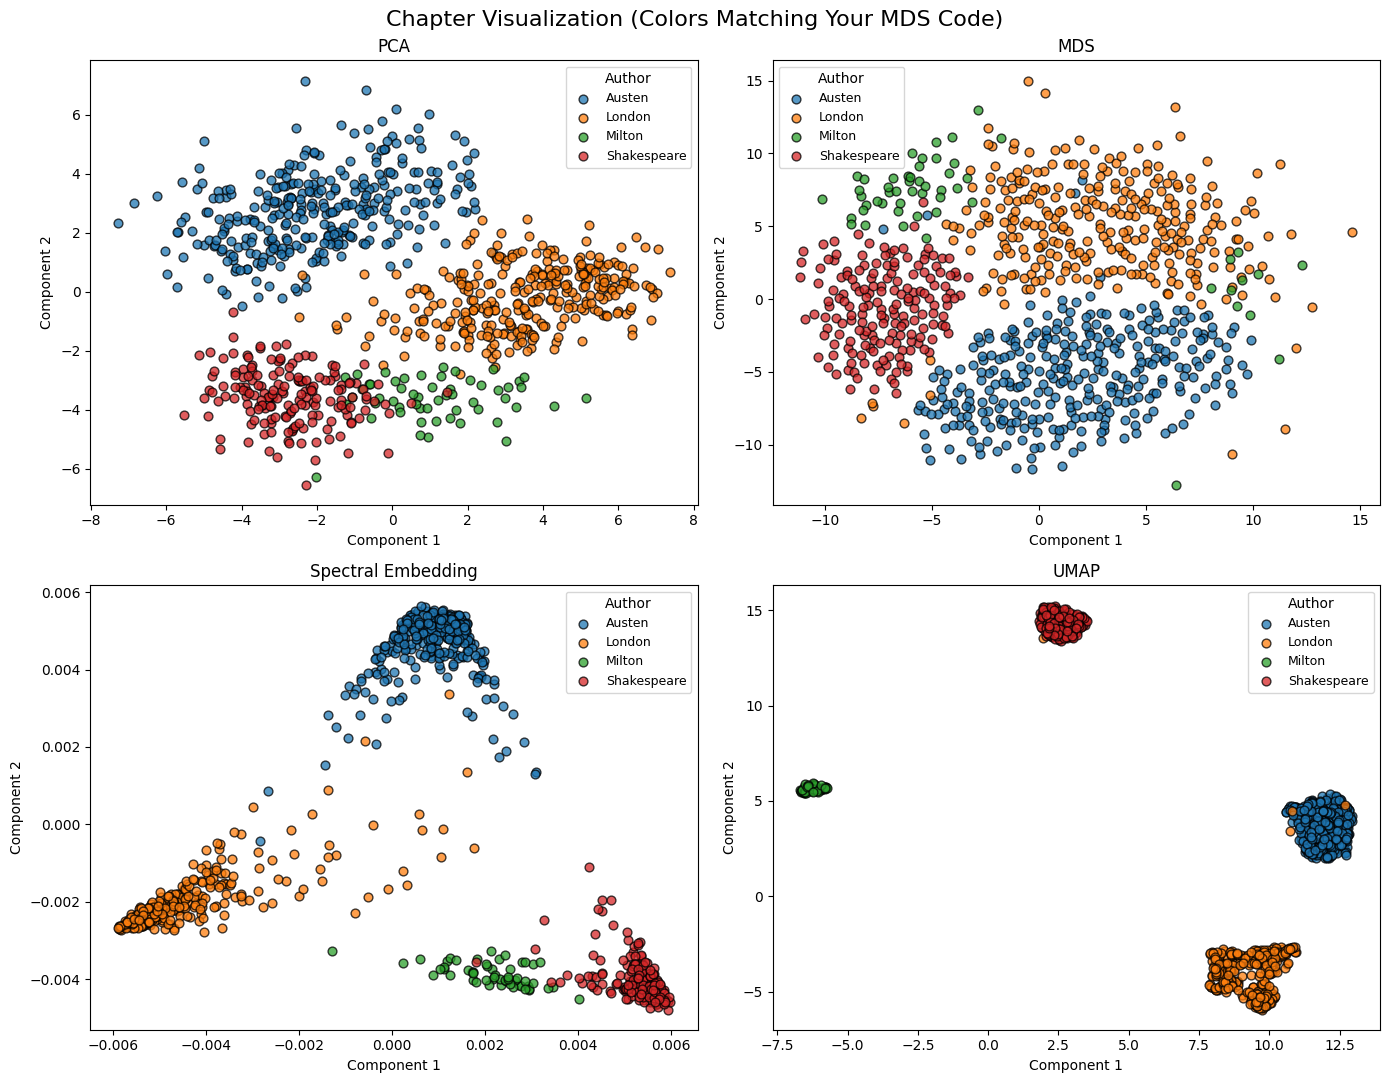

In [169]:
X_raw = data.copy()
X = X_raw.values
labels_series = pd.Series(data.index)
unique_authors = labels_series.unique().tolist()
labels_numeric = labels_series.apply(lambda x: unique_authors.index(x)).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
author_colors = dict(zip(unique_authors, default_colors))

def reduce_and_plot(X, method, method_name, ax):
    X_red = method.fit_transform(X)
    for i, author in enumerate(unique_authors):
        mask = (labels_series == author)
        ax.scatter(X_red[mask, 0], X_red[mask, 1],
                   label=author,
                   color=author_colors[author],
                   edgecolor='k', alpha=0.75, s=40)
    ax.set_title(method_name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(title="Author", loc="best", fontsize=9)

pca = PCA(n_components=2)
mds = MDS(n_components=2, random_state=0)
spectral = SpectralEmbedding(n_components=2, random_state=0)
umap_model = umap.UMAP(n_components=2, random_state=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

reduce_and_plot(X_scaled, pca, "PCA", axes[0, 0])
reduce_and_plot(X_scaled, mds, "MDS", axes[0, 1])
reduce_and_plot(X_scaled, spectral, "Spectral Embedding", axes[1, 0])
reduce_and_plot(X_scaled, umap_model, "UMAP", axes[1, 1])

plt.suptitle("Chapter Visualization (Colors Matching Your MDS Code)", fontsize=16)
plt.tight_layout()
plt.show()

In the first Figure, PCA provides a clean, interpretable linear projection of the data, where chapters are mapped onto the directions of maximum variance. In the visualization, Austen and Shakespeare form well-separated clusters, while Milton and London exhibit significant overlap, making them harder to distinguish. Although PCA’s components are directly interpretable and useful for understanding which features contribute most to variance, it is limited by its linear nature. It cannot capture more complex, nonlinear stylistic differences between authors. As a result, while PCA offers strong interpretability and serves as a good baseline, its clustering clarity is moderate.

In the second figure, Multidimensional Scaling (MDS) with Euclidean distance aims to preserve the pairwise distances between chapters when projecting them into two dimensions. The resulting plot shows relatively clear separation for some authors, such as Austen and Shakespeare, but Milton and London again overlap considerably. This method helps maintain the overall geometry of the data and offers moderate interpretability. However, Euclidean distance may not be the best choice for high-dimensional, sparse word frequency data, which weakens its ability to form visually distinct clusters. Overall, MDS provides a reasonably faithful low-dimensional representation, but lacks the power to clearly separate all classes.

In the third Figure, Spectral Embedding uncovers manifold structures in the data by treating chapters as nodes in a graph and embedding them based on their local connectivity. The resulting visualization forms a curved, stream-like shape, suggesting underlying structural relationships in the data. While Austen and Shakespeare are somewhat separated, Milton and London remain partially entangled, and the cluster boundaries are not well defined. Spectral embedding is effective for capturing nonlinear data geometry, but the axes lack interpretability, and the method is sensitive to neighborhood parameters. Thus, while it offers insight into hidden relationships, it is less effective for straightforward clustering interpretation.

In the last Figure, UMAP stands out as the most effective method for visualizing distinct author styles. It produces four compact, clearly separated clusters corresponding to the authors, with minimal to no overlap. This makes it highly effective for visual clustering and identifying group patterns. UMAP preserves local neighborhood structures while maintaining a coherent global view. Although the axes are not interpretable and results can vary with initialization, UMAP is especially well-suited for high-dimensional, sparse data like text. Its clarity and strong class separation make it the most interpretable method in a visual sense, even though it lacks component-level explanations.

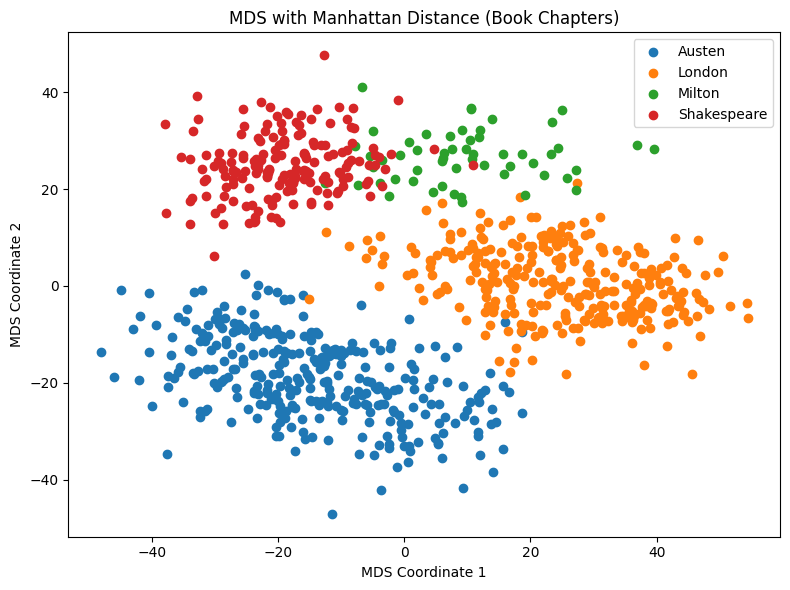

In [176]:
Dmat = pairwise_distances(data_scaled, metric='cityblock')

mdsres = classical_mds(Dmat, k=2)

unique_authors = pd.Series(data.index).unique()
plt.figure(figsize=(8, 6))

for author in unique_authors:
    mask = (np.array(data.index) == author)
    plt.scatter(mdsres[mask, 0], mdsres[mask, 1], label=str(author))

plt.xlabel("MDS Coordinate 1")
plt.ylabel("MDS Coordinate 2")
plt.title("MDS with Manhattan Distance (Book Chapters)")
plt.legend()
plt.tight_layout()
plt.show()

Classical MDS using the Manhattan (cityblock) distance yields one of the clearest and most structured visualizations. Unlike Euclidean MDS, this version is better adapted to sparse, count-based text data, capturing important differences in word usage patterns. In the plot, all four authors are distinctly separated, including Milton and London, which previously overlapped in other methods. The structure is simple, layered, and easy to interpret. Though the axes do not have specific meanings, the overall geometry offers strong interpretability and is especially effective for this type of data. As such, this method serves as a robust, classical baseline with excellent clustering performance.

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1692: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Text(0.5, 1.0, 'NMF on observations')

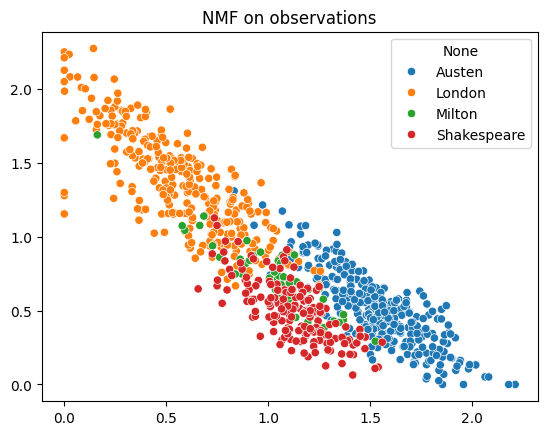

In [172]:
nmf = NMF(n_components=2, init='nndsvda', random_state=0)
X_nmf = nmf.fit_transform(data)

sns.scatterplot(x = X_nmf[:,0], y = X_nmf[:,1], hue = data.index)
plt.title('NMF on observations')

#### Below are some extended results from my attempts at applying different distance metrics and varying the number of neighbors in the UMAP method. However, in terms of visualization, there is essentially no significant difference — the results still demonstrate that the UMAP method provides very interpretable visualizations.

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


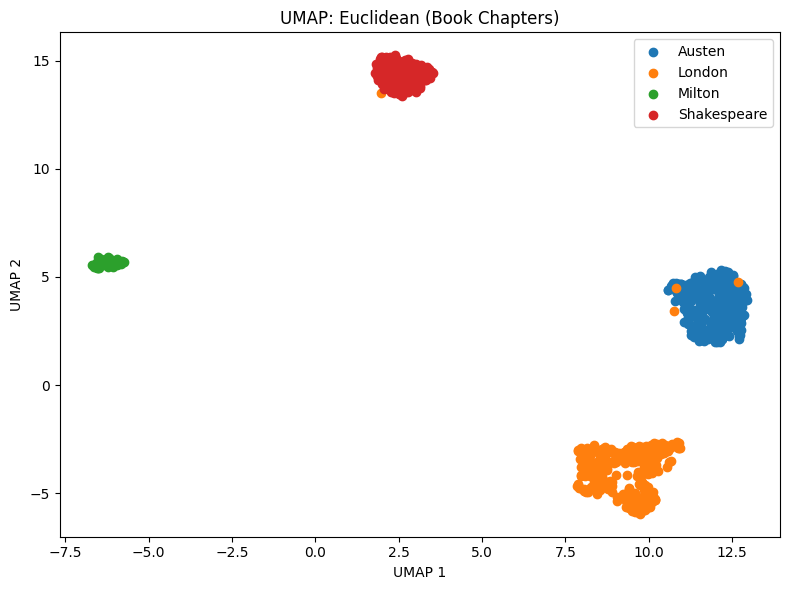

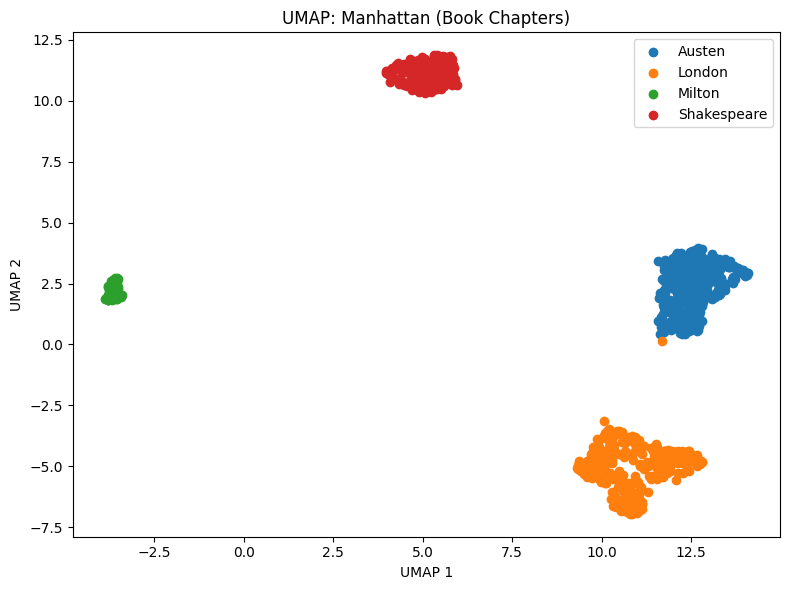

In [144]:
umap_euc = umap.UMAP(metric="euclidean", random_state=0).fit(data_scaled)
umap_manh = umap.UMAP(metric="manhattan", random_state=0).fit(data_scaled)

unique_authors = pd.Series(data.index).unique()

plt.figure(figsize=(8,6))
for author in unique_authors:
    mask = (np.array(data.index) == author)
    plt.scatter(umap_euc.embedding_[mask, 0], umap_euc.embedding_[mask, 1], label=str(author))
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP: Euclidean (Book Chapters)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
for author in unique_authors:
    mask = (np.array(data.index) == author)
    plt.scatter(umap_manh.embedding_[mask, 0], umap_manh.embedding_[mask, 1], label=str(author))
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP: Manhattan (Book Chapters)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


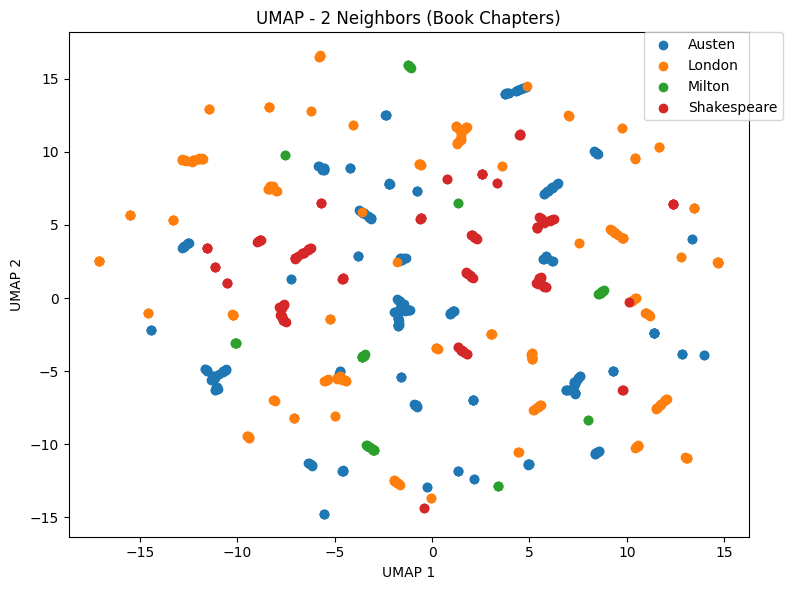

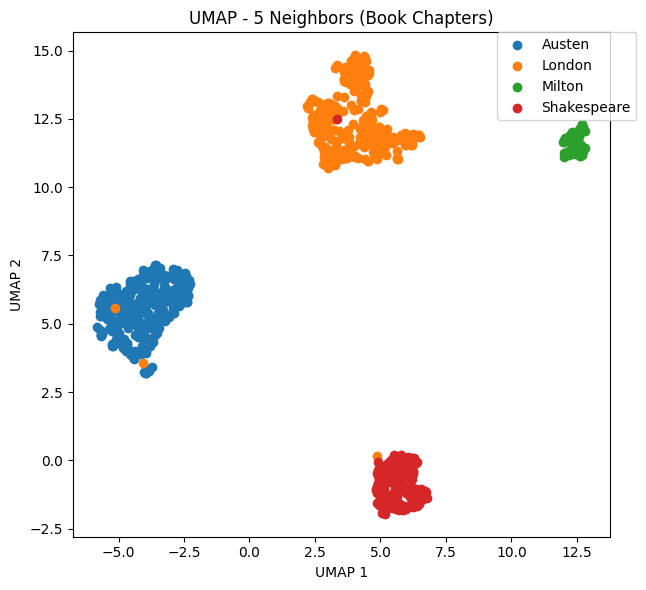

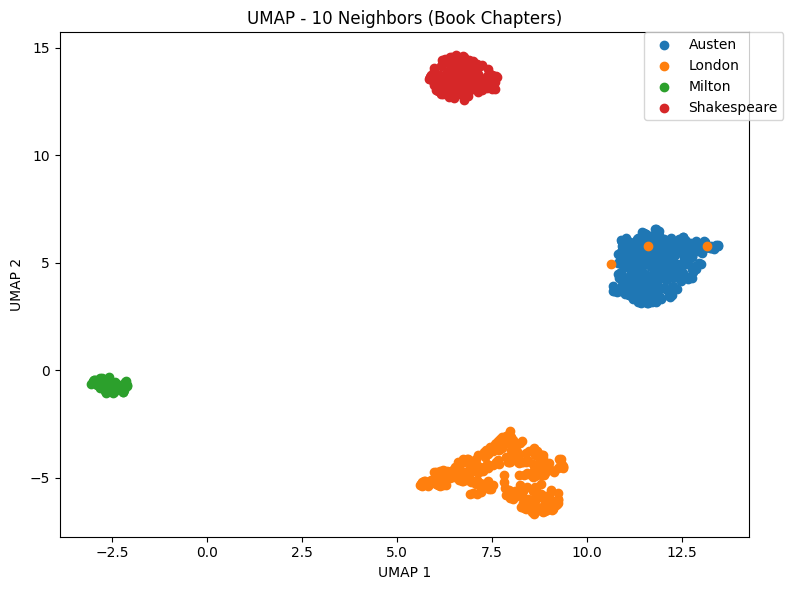

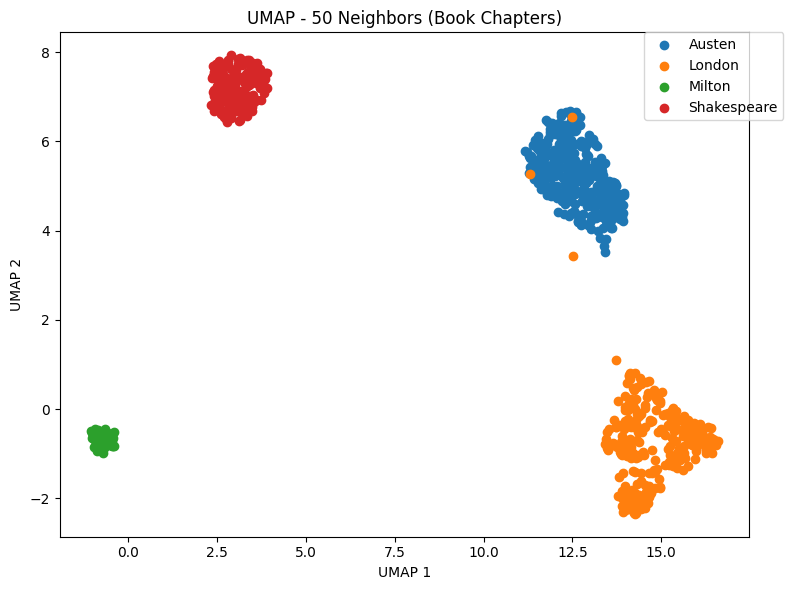

In [154]:
nneighs = [2, 5, 10, 50]
umap_results = {}

for n in nneighs:
    umap_results[n] = UMAP(n_neighbors=n, random_state=0).fit(data_scaled)

unique_authors = pd.Series(data.index).unique()

for n in nneighs:
    plt.figure(figsize=(8, 6))
    for author in unique_authors:
        mask = (np.array(data.index) == author)
        plt.scatter(
            umap_results[n].embedding_[mask, 0],
            umap_results[n].embedding_[mask, 1],
            label=str(author)
        )
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP - {n} Neighbors (Book Chapters)")
    plt.legend(loc="best", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

## Interpretation and Conclusion:
Among all the methods tested, UMAP and Classical MDS (with Manhattan distance) provide the most interpretable visual representations of the chapter data. UMAP excels in clearly separating authors into compact, well-defined clusters, which is highly informative for visual categorization. Classical MDS, especially when paired with Manhattan distance, retains much of the natural dissimilarity in the high-dimensional space while presenting it in a globally coherent way. In contrast, PCA and Euclidean MDS preserve variance and distances but fail to reveal non-linear structures or clear author separation in some cases. Spectral embedding uncovers manifold structures, but its interpretability is limited in terms of author classification.

## (b) features (words)

In [155]:
X_words = data.T

In [156]:
X_words.head()

,Austen,Austen,Austen,Austen,Austen,Austen,Austen,Austen,Austen,Austen,...,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare,Shakespeare
a,46.0,35.0,46.0,40.0,29.0,27.0,34.0,38.0,34.0,54.0,...,46.0,48.0,39.0,22.0,28.0,32.0,16.0,22.0,25.0,26.0
all,12.0,10.0,2.0,7.0,5.0,8.0,8.0,6.0,12.0,8.0,...,4.0,2.0,5.0,13.0,7.0,4.0,5.0,15.0,4.0,4.0
also,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
an,3.0,7.0,3.0,4.0,6.0,3.0,15.0,2.0,5.0,6.0,...,3.0,9.0,10.0,5.0,7.0,6.0,5.0,3.0,8.0,2.0
and,66.0,44.0,40.0,64.0,52.0,42.0,44.0,67.0,50.0,44.0,...,43.0,45.0,38.0,47.0,45.0,33.0,49.0,48.0,59.0,62.0


In [157]:
X_words_scaled = StandardScaler().fit_transform(X_words)

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


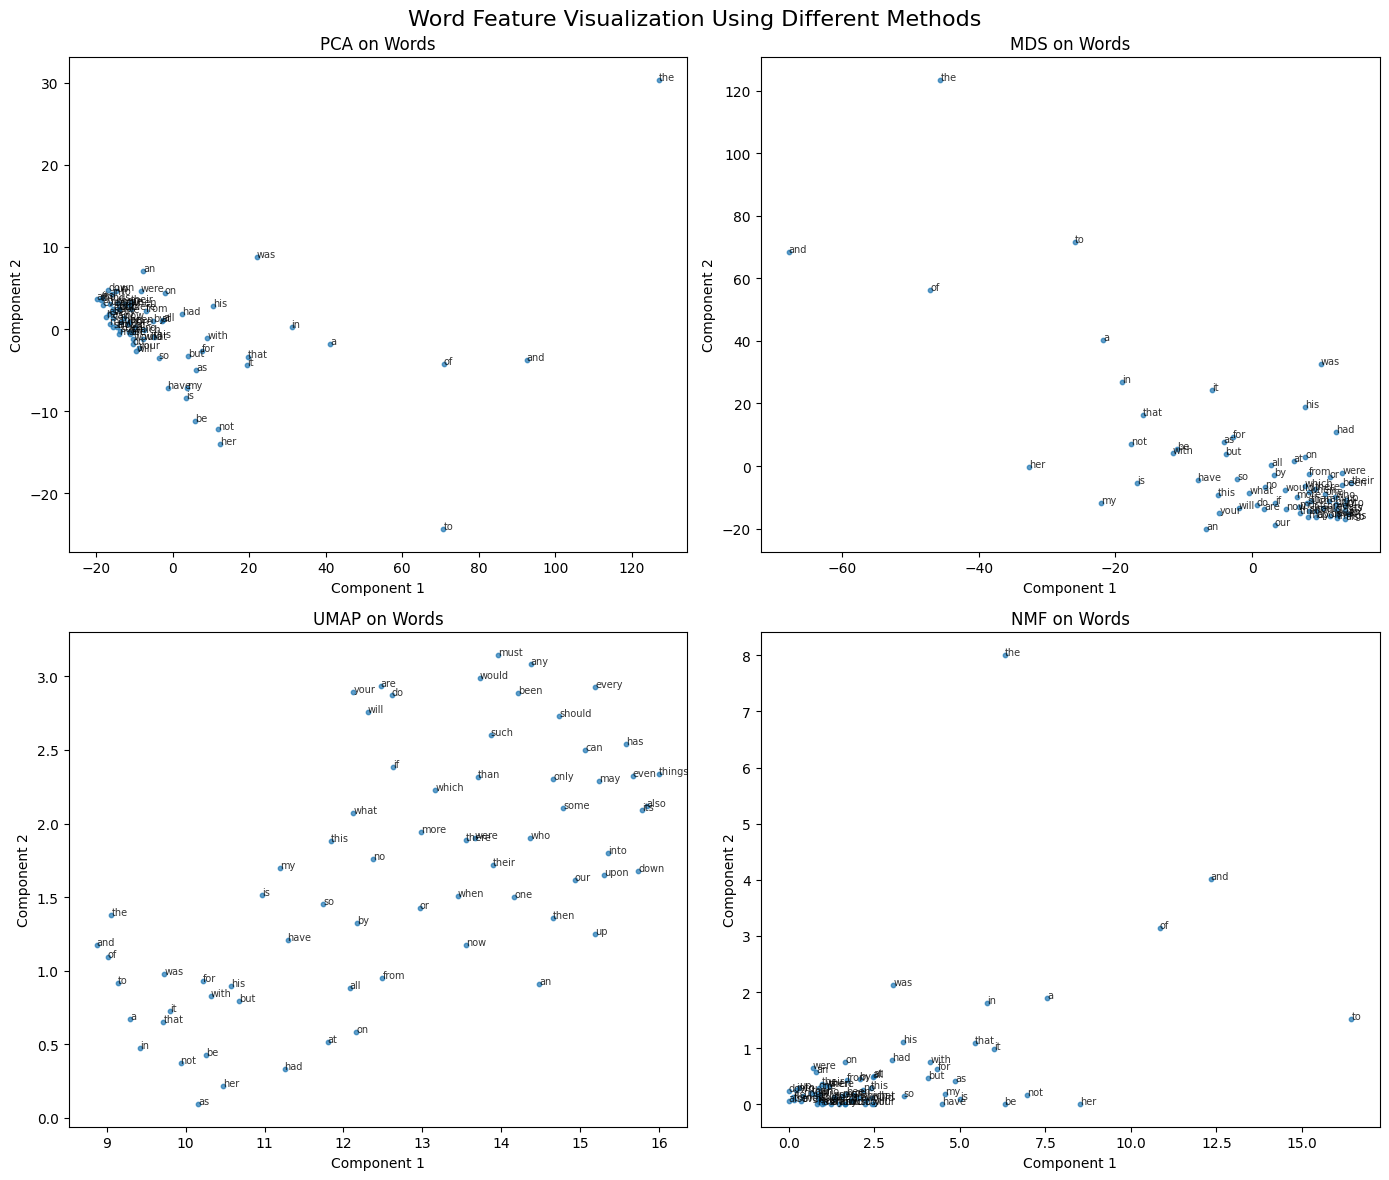

In [170]:
X_words = data.T
words = X_words.index.tolist() 
X_words_scaled = StandardScaler().fit_transform(X_words)

pca = PCA(n_components=2)
mds = MDS(n_components=2, random_state=0)
umap_model = umap.UMAP(n_components=2, random_state=0)
nmf_model = NMF(n_components=2, init='nndsvda', random_state=0)

def plot_word_embedding(X_emb, title, words, ax):
    ax.scatter(X_emb[:, 0], X_emb[:, 1], alpha=0.7, s=10)
    for i, word in enumerate(words):
        ax.text(X_emb[i, 0], X_emb[i, 1], word, fontsize=7, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_word_embedding(pca.fit_transform(X_words_scaled), "PCA on Words", words, axes[0, 0])
plot_word_embedding(mds.fit_transform(X_words_scaled), "MDS on Words", words, axes[0, 1])
plot_word_embedding(umap_model.fit_transform(X_words_scaled), "UMAP on Words", words, axes[1, 0])
plot_word_embedding(nmf_model.fit_transform(X_words), "NMF on Words", words, axes[1, 1])

plt.suptitle("Word Feature Visualization Using Different Methods", fontsize=16)
plt.tight_layout()
plt.show()

In the fisrt Figure, PCA applied to words shows a fairly tight cluster of most words, with a few extreme outliers—like “the”, “and”, “of”—appearing far from the center. These outliers likely correspond to very high-frequency, function words that dominate the variance structure. The first principal component thus seems to capture overall word frequency, separating stopwords from the rest. While the layout clearly reflects frequency-based variance, there is little interpretable group structure beyond this, and most words remain tightly packed with little visual separation.


In the second Figure, MDS on words reveals a similar pattern to PCA, but the high-frequency words like “the”, “and”, and “of” again dominate the spatial layout. Most words are compressed into a small region of space, while a few are flung out far away, which suggests the distance matrix was heavily influenced by frequency magnitude. Like PCA, this highlights word prominence but does not offer useful visual grouping or proximity-based semantic interpretation.



In the third Figure, UMAP provides the most visually informative and structured layout of words. It spreads out the vocabulary into a lattice-like pattern, where semantically or syntactically similar words (e.g., modal verbs, pronouns, prepositions) are placed closer together. This suggests that UMAP has successfully captured local co-occurrence or contextual usage similarities in the word profiles across chapters. Additionally, no words dominate the layout, and clusters are more visually coherent.

In the last Figure, NMF, when applied to words, produces a sparse embedding that aligns along distinct linear directions. A few words—especially high-frequency ones like “the”, “and”—are pulled far from the rest. Most words are packed near the origin, indicating limited variation across the derived non-negative components. This visualization is useful in that the axes correspond to latent “topics” or word usage patterns, but visually it provides minimal separation or structure between most words.



#### Next, I generated some additional results by experimenting with different distance metrics and adjusting the number of neighbors in the UMAP method. I found that when using the Euclidean distance and setting the number of neighbors to 5, 10, or 50, the visualization quality improved noticeably.

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


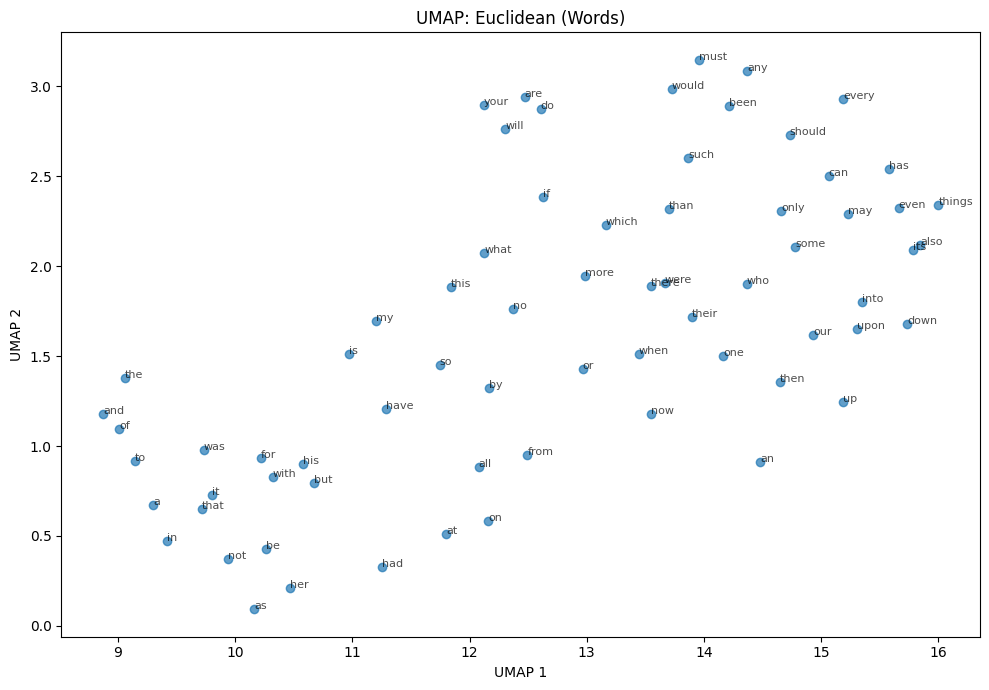

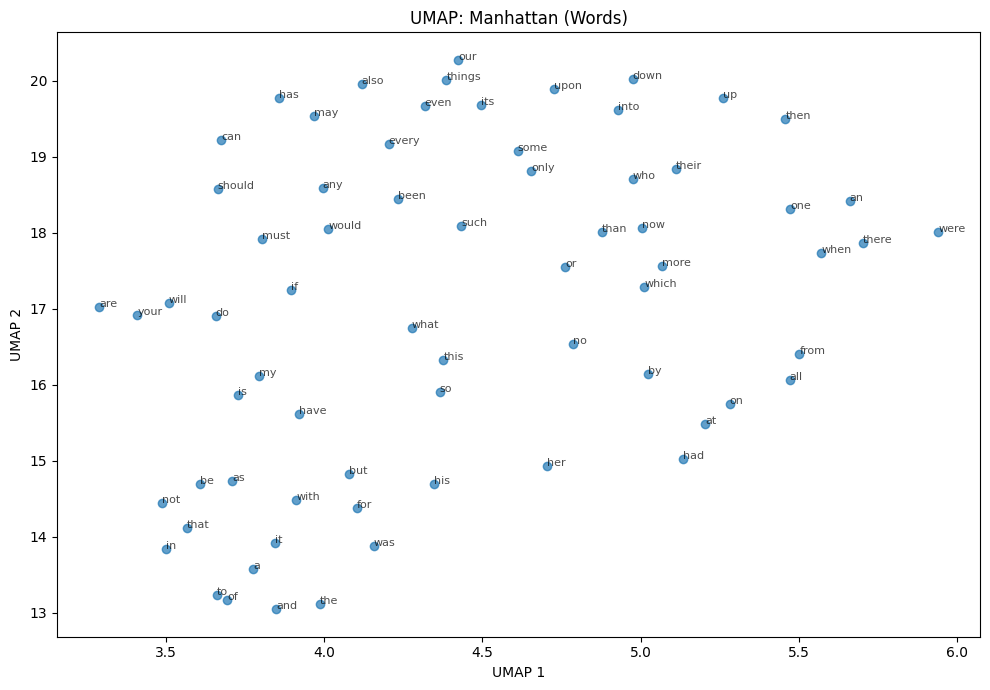

In [159]:
umap_euc = umap.UMAP(metric="euclidean", random_state=0).fit(X_T_scaled)
umap_manh = umap.UMAP(metric="manhattan", random_state=0).fit(X_T_scaled)

words = data_transpose.index.to_list()

plt.figure(figsize=(10, 7))
plt.scatter(umap_euc.embedding_[:, 0], umap_euc.embedding_[:, 1], alpha=0.7)
for i, word in enumerate(words):
    plt.text(umap_euc.embedding_[i, 0], umap_euc.embedding_[i, 1], word, fontsize=8, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP: Euclidean (Words)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(umap_manh.embedding_[:, 0], umap_manh.embedding_[:, 1], alpha=0.7)
for i, word in enumerate(words):
    plt.text(umap_manh.embedding_[i, 0], umap_manh.embedding_[i, 1], word, fontsize=8, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP: Manhattan (Words)")
plt.tight_layout()
plt.show()

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


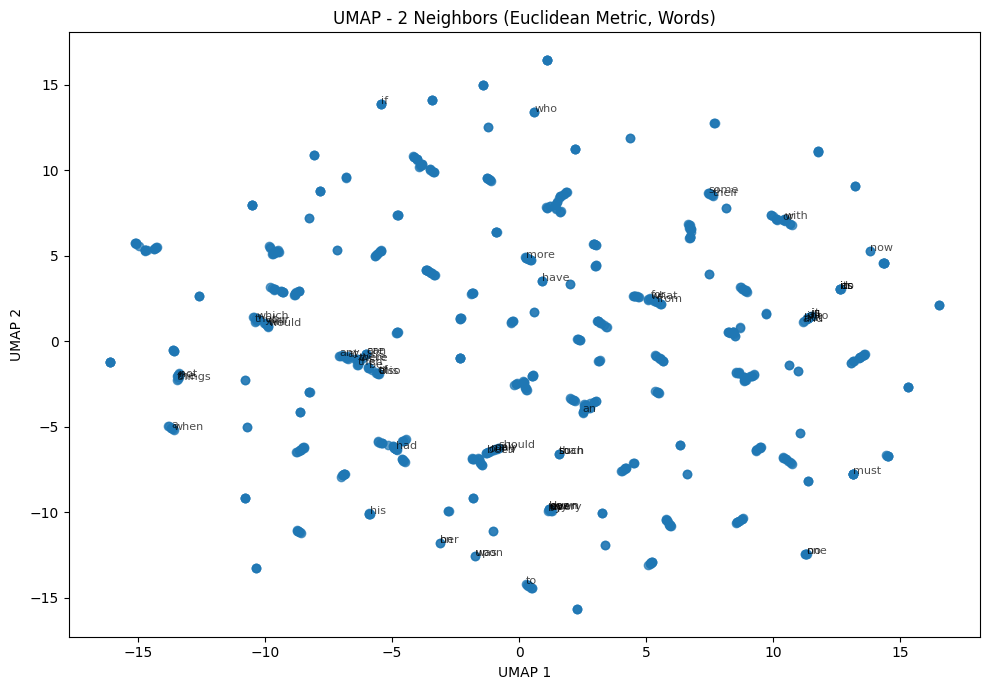

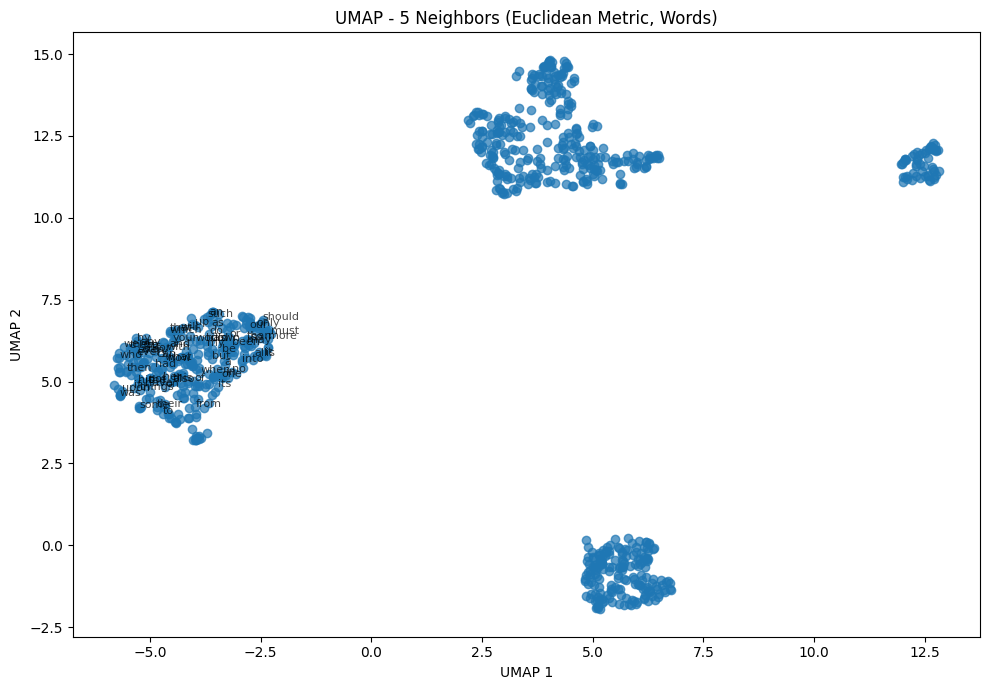

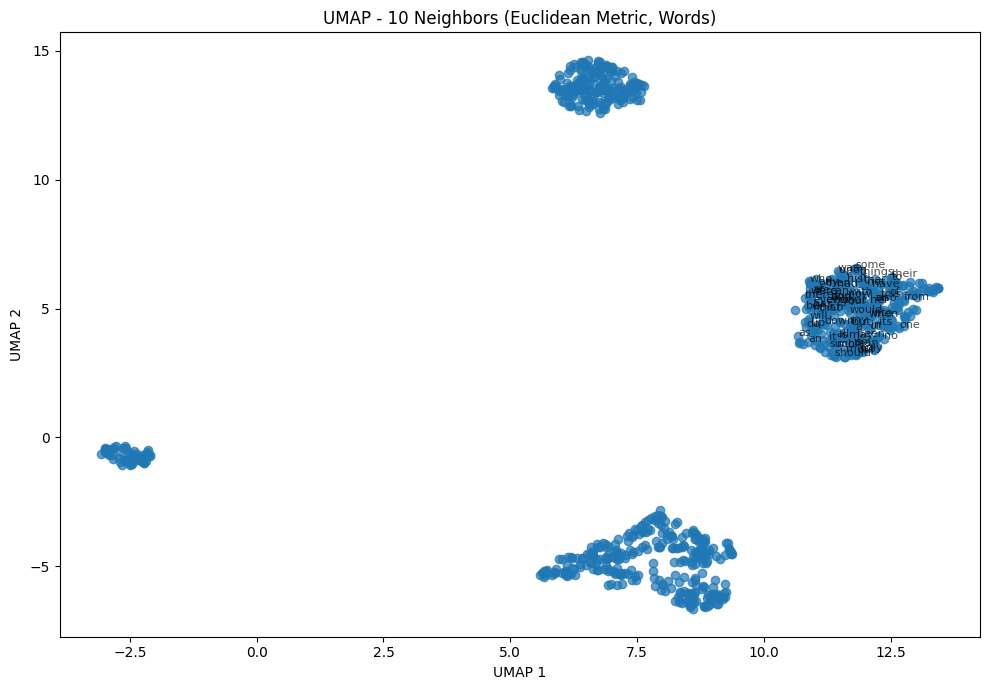

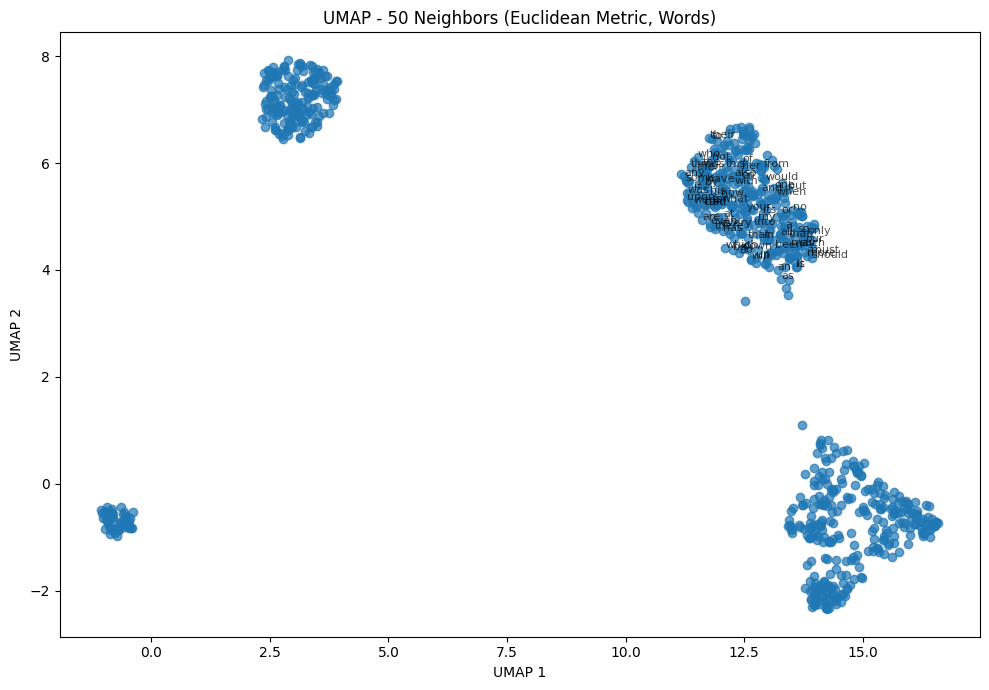

In [111]:
nneighs = [2, 5, 10, 50]
umap_results = {}

for n in nneighs:
    reducer = umap.UMAP(n_neighbors=n, metric='euclidean', random_state=0)
    umap_results[n] = reducer.fit(data_scaled)

words = data_transpose.index.to_list()

for n in nneighs:
    plt.figure(figsize=(10, 7))
    plt.scatter(
        umap_results[n].embedding_[:, 0],
        umap_results[n].embedding_[:, 1],
        alpha=0.7
    )
    for i, word in enumerate(words):
        plt.text(
            umap_results[n].embedding_[i, 0],
            umap_results[n].embedding_[i, 1],
            word,
            fontsize=8,
            alpha=0.7
        )
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP - {n} Neighbors (Euclidean Metric, Words)")
    plt.tight_layout()
    plt.show()

## Interpretation and Conclusion:
Among the four methods, UMAP provides the most interpretable and visually meaningful representation of words. It successfully distributes words in a way that reflects semantic and syntactic similarity, making it ideal for exploring word usage patterns across chapters. PCA and MDS reflect raw frequency but lack structure, while NMF offers component-level interpretability but minimal visual spread.

## (c) both observations and features. 

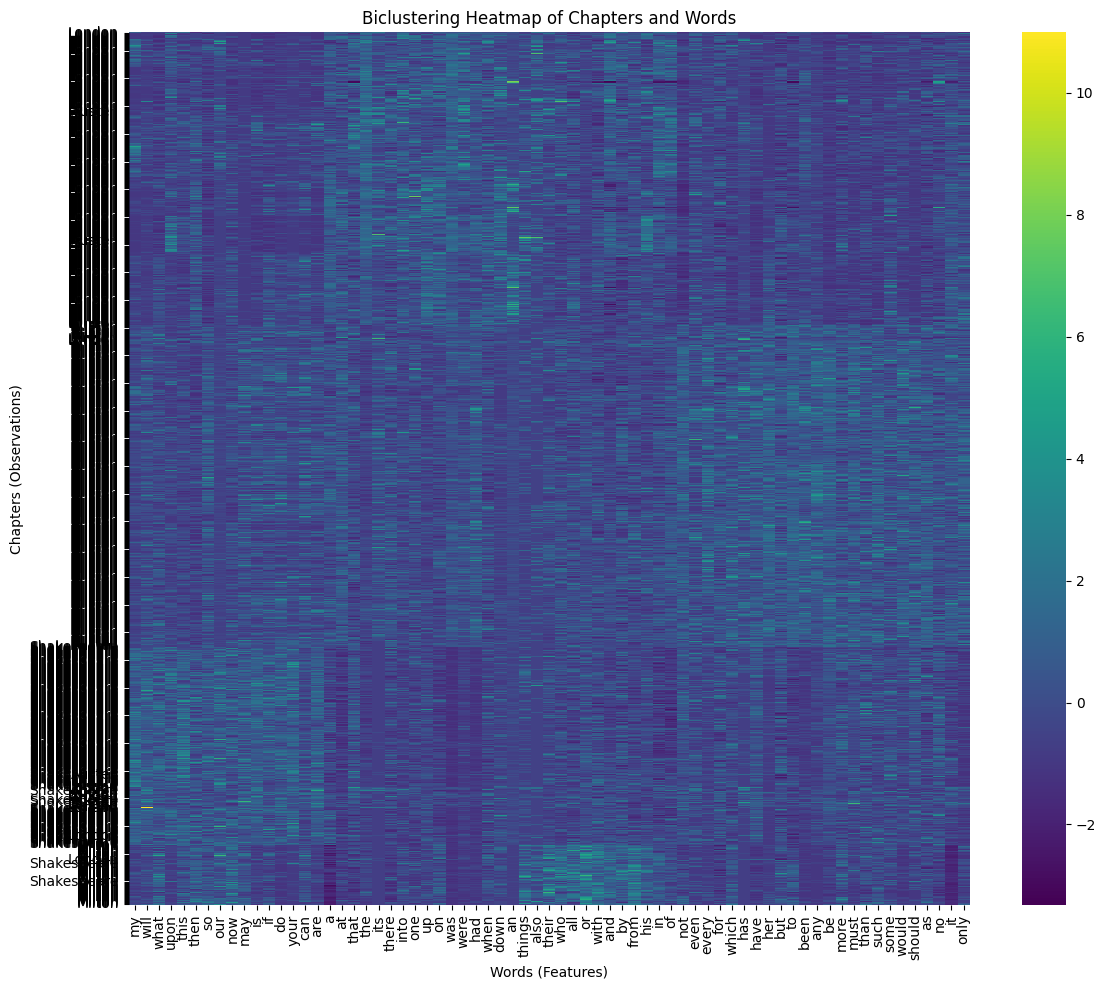

In [163]:
data_scaled = StandardScaler().fit_transform(data)
data_scaled_df = pd.DataFrame(data_scaled, index=data.index, columns=data.columns)

bicluster = SpectralBiclustering(n_clusters=4, random_state=0)
bicluster.fit(data_scaled_df)

row_order = np.argsort(bicluster.row_labels_)
col_order = np.argsort(bicluster.column_labels_)

data_biclustered = data_scaled_df.iloc[row_order, col_order]

plt.figure(figsize=(12, 10))
sns.heatmap(data_biclustered, cmap="viridis", xticklabels=True, yticklabels=True, cbar=True)
plt.title("Biclustering Heatmap of Chapters and Words")
plt.xlabel("Words (Features)")
plt.ylabel("Chapters (Observations)")
plt.tight_layout()
plt.show()

## Interpretation and Analysis:
In this diagram, the heat map shows enhanced or diminished blocks of color that correspond to subsets of words that appear frequently in chapter subsets. This type of visualization is particularly useful for spotting local patterns - for example, specific groups of words that are closely related to a particular author's writing style or a particular set of texts.This suggests that the dataset may lack strong local patterns of chapter-word interaction, or that such structure is too weak or too diffuse to be captured by spectral biclustering in this form. It’s also possible that the preprocessed input (e.g., word frequency normalized and standardized) does not align well with the assumptions of biclustering algorithms, which are often most effective on sparse binary or strongly skewed count data. Moreover, the large number of chapters and words, combined with a relatively dense word distribution, may further obscure the emergence of clear blocks.

Visually, the results show several horizontal and vertically aligned block patterns, indicating the presence of chapter clusters and word clusters. These blocks indicate that some words are preferentially used for a specific subset of the chapter, possibly consistent with authorship or genre. Compared to dimensional-reduction scatter plots, this method is excellent at revealing "local structures" where multiple chapters-word relationships are active only in a limited area, rather than globally across the entire dataset.

Overall evaluation:
Biclustering provides a powerful visual summary of local co-occurrence structures between chapters and words, revealing potential barriers to stylistic or thematic consistency. It is especially useful for identifying word subgroups and chapter fragments with similar usage patterns. However, its interpretability is limited by the lack of axis readability and spatial continuity.

#### b) Clustering. Compare and contrast several clustering methods including K-means, hierarchical clustering (with several linkages and distances), Gaussian mixture models, and spectral clustering. You may also wish to combine dimension reduction techniques with clustering. Which method is best at correctly grouping texts from the four authors? (Here you have the true authorship labels that you can use to understand clustering accuracy). Report your clustering accuracy for each method and visualize your results. Interpret and reflect upon your results.

In [84]:
pca = PCA(n_components=50, random_state=0)
data_pca = pca.fit_transform(data_scaled)

In [91]:
from sklearn.preprocessing import LabelEncoder
true_labels = LabelEncoder().fit_transform(data.index)

In [92]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
from scipy.stats import mode

kmeans = KMeans(n_clusters=4, random_state=0)
kmeans_labels = kmeans.fit_predict(data_pca)

def remap_labels(true, pred):
    labels = np.zeros_like(pred)
    for i in range(4):
        mask = (pred == i)
        labels[mask] = mode(true[mask])[0]
    return labels

kmeans_labels_remap = remap_labels(true_labels, kmeans_labels)
kmeans_acc = accuracy_score(true_labels, kmeans_labels_remap)
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
print(f"K-means Accuracy: {kmeans_acc:.3f}, ARI: {kmeans_ari:.3f}")


K-means Accuracy: 0.981, ARI: 0.948


/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


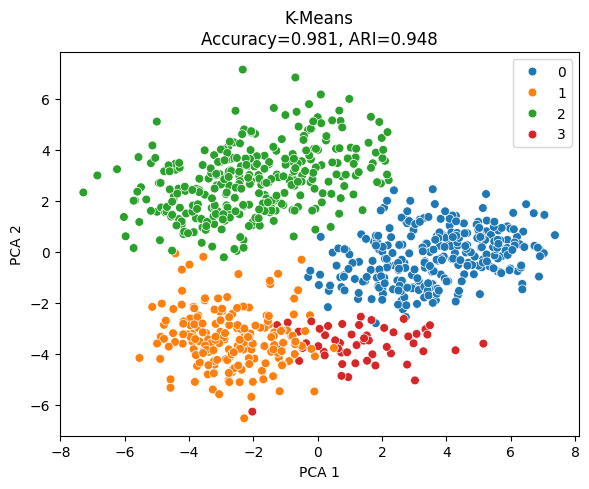

In [93]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=kmeans_labels, palette='tab10', s=40)
plt.title(f"K-Means\nAccuracy={kmeans_acc:.3f}, ARI={kmeans_ari:.3f}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

K-Means Clustering
 • Accuracy: 0.981
 • ARI: 0.948
 
K-means also produces excellent results. The clusters are compact and well-separated, and the ARI shows strong consistency with true labels. This performance demonstrates that K-means is highly effective when the data is well-represented in a reduced-dimensional Euclidean space such as PCA.


/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


Hierarchical (ward) Accuracy: 0.994, ARI: 0.983


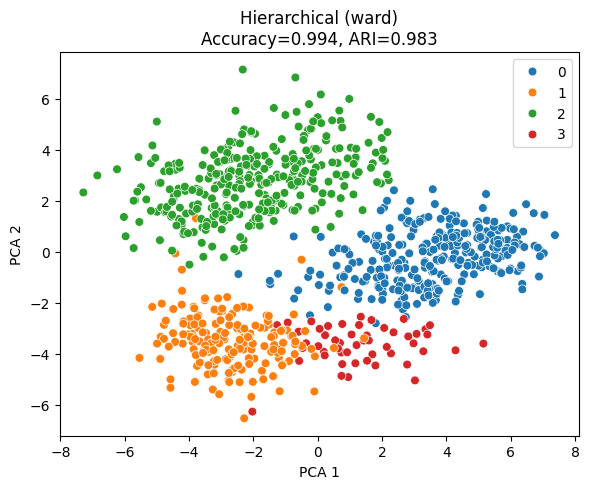

/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


Hierarchical (complete) Accuracy: 0.718, ARI: 0.515


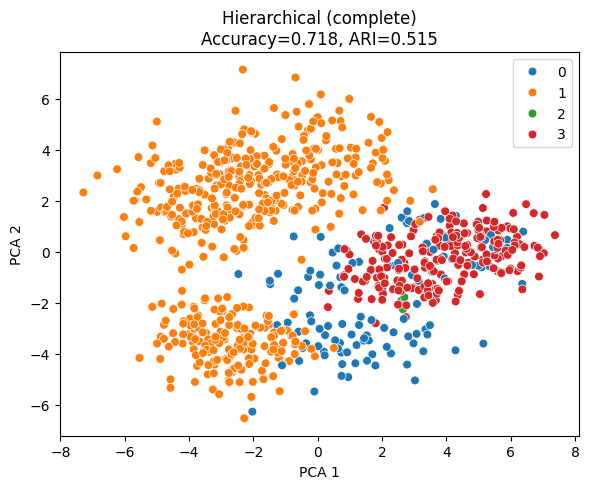

/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


Hierarchical (average) Accuracy: 0.384, ARI: -0.002


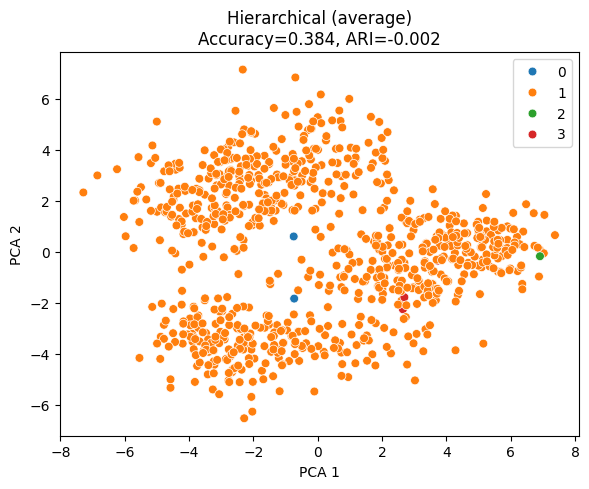

In [179]:
for link in linkages:
    hc = AgglomerativeClustering(n_clusters=4, linkage=link)
    hc_labels = hc.fit_predict(data_pca)
    hc_labels_remap = remap_labels(true_labels, hc_labels)
    acc = accuracy_score(true_labels, hc_labels_remap)
    ari = adjusted_rand_score(true_labels, hc_labels)

    print(f"Hierarchical ({link}) Accuracy: {acc:.3f}, ARI: {ari:.3f}")

    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=hc_labels, palette='tab10', s=40)
    plt.title(f"Hierarchical ({link})\nAccuracy={acc:.3f}, ARI={ari:.3f}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()

Hierarchical Clustering (Ward Linkage)
 • Accuracy: 0.994
 • ARI: 0.983

Ward linkage performs exceptionally well in this case. The resulting clusters are visually compact, highly distinct in PCA space, and almost perfectly aligned with the actual authors. The ARI near 1 indicates a very strong match to the true author labels. This method is the best among hierarchical variants.

Hierarchical Clustering (Complete Linkage)
 • Accuracy: 0.718
 • ARI: 0.515

This method performs moderately well, separating some of the clusters in PCA space. While not perfect, complete linkage provides a better balance of inter-cluster compactness and separation than average linkage, resulting in visibly distinguishable groups with moderate clustering agreement with ground truth.

Hierarchical Clustering (Average Linkage)
 • Accuracy: 0.384
 • ARI: -0.002

This method performs poorly, assigning nearly all points to a single cluster. The near-zero ARI indicates that the predicted clustering structure is essentially random with respect to the true labels. This suggests that average linkage fails to capture meaningful inter-cluster separation for this dataset, particularly when combined with PCA-based distance information.



In [180]:
gmm = GaussianMixture(n_components=4, random_state=0)
gmm_labels = gmm.fit_predict(data_pca)
gmm_labels_remap = remap_labels(true_labels, gmm_labels)
gmm_acc = accuracy_score(true_labels, gmm_labels_remap)
gmm_ari = adjusted_rand_score(true_labels, gmm_labels)
print(f"GMM Accuracy: {gmm_acc:.3f}, ARI: {gmm_ari:.3f}")

GMM Accuracy: 0.920, ARI: 0.725


/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


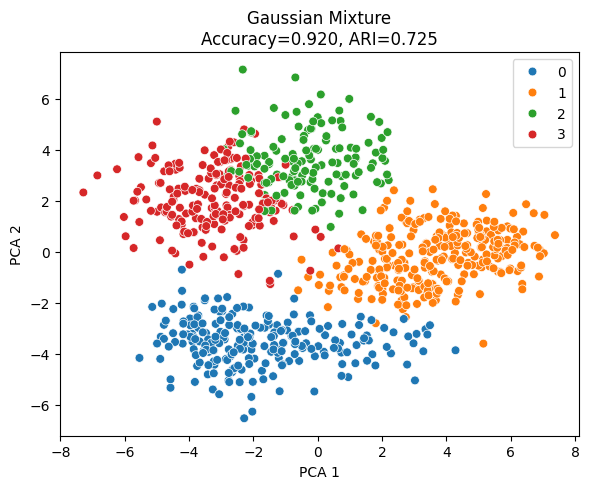

In [105]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=gmm_labels, palette='tab10', s=40)
plt.title(f"Gaussian Mixture\nAccuracy={gmm_acc:.3f}, ARI={gmm_ari:.3f}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

Gaussian Mixture Models (GMM)
 • Accuracy: 0.920
 • ARI: 0.725

GMM provides good but slightly weaker clustering than K-means and Ward. It allows for elliptical cluster shapes and soft assignments, which can capture overlapping clusters better in theory. However, in this case, the overlap between authors like Milton and Shakespeare leads to more mixing and thus a lower ARI.


In [106]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=0)
spectral_labels = spectral.fit_predict(data_pca)
spectral_labels_remap = remap_labels(true_labels, spectral_labels)
spectral_acc = accuracy_score(true_labels, spectral_labels_remap)
spectral_aci = adjusted_rand_score(true_labels, spectral_labels)
print(f"Spectral Accuracy: {spectral_acc:.3f}, ARI: {spectral_ari:.3f}")

Spectral Accuracy: 0.995, ARI: 0.985


/var/folders/s1/2r578vx153d8cmbdps9ln15m0000gn/T/ipykernel_42057/1784713998.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(true[mask])[0]


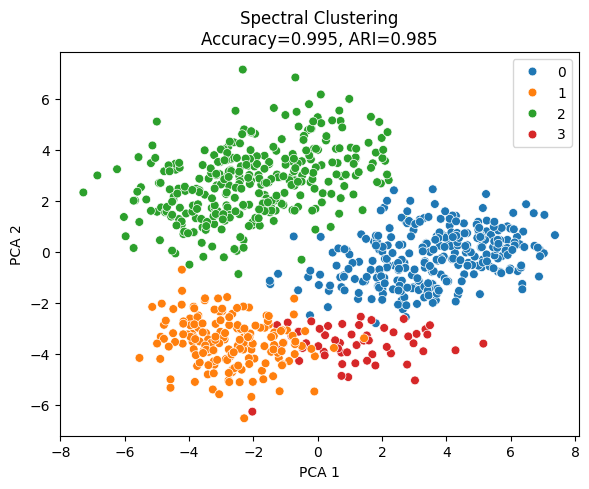

In [107]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue = spectral_labels, palette='tab10', s=40)
plt.title(f"Spectral Clustering\nAccuracy={spectral_acc:.3f}, ARI={spectral_aci:.3f}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

Spectral Clustering
 • Accuracy: 0.995
 • ARI: 0.985

Spectral clustering gives the best performance overall, achieving both near-perfect accuracy and ARI. The method effectively utilizes the local neighborhood graph structure in the data and captures complex relationships not easily modeled by centroid-based approaches. The visual separation is crisp, and the alignment with ground truth labels is almost perfect.

## Conclusion

Among all methods tested, Spectral Clustering and Ward’s Hierarchical Clustering stand out as the most effective for correctly grouping texts by author. They achieve near-perfect alignment with true labels and visually exhibit highly distinct clusters. K-means also performs extremely well and is simpler to implement. On the other hand, Average Linkage fails to separate the clusters meaningfully and performs no better than random. These results suggest that methods capturing global structure (Ward) or local similarity (Spectral) are better suited for this task, especially when combined with PCA for dimensionality reduction.

#### c) Pattern Recognition. Are there major observation and/or feature patterns in the data? Which words or sets of words are important for correctly grouping the author texts (in an unsupervised manner). Which methods did you use for this? Why? Visualize, interpret and reflect upon your results.

In [195]:
assert (data.values >= 0).all(), "NMF requires non-negative input."

nmf = NMF(n_components=4, init='nndsvda', random_state=0)
W = nmf.fit_transform(data)
H = nmf.components_

feature_names = data.columns

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: to, her, and, of, was, be, had, not, as, it
Topic 2: the, was, of, a, and, in, it, had, that, an
Topic 3: the, a, to, my, is, of, and, that, it, not
Topic 4: and, the, of, to, his, in, with, from, all, their


NMF was applied to the word-by-chapter frequency matrix to uncover latent “topics” or components that capture shared word usage patterns. Since NMF constrains the decomposition to non-negative components, it tends to yield interpretable, part-based representations. Each topic revealed a set of words strongly associated with a style or authorial pattern.


/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


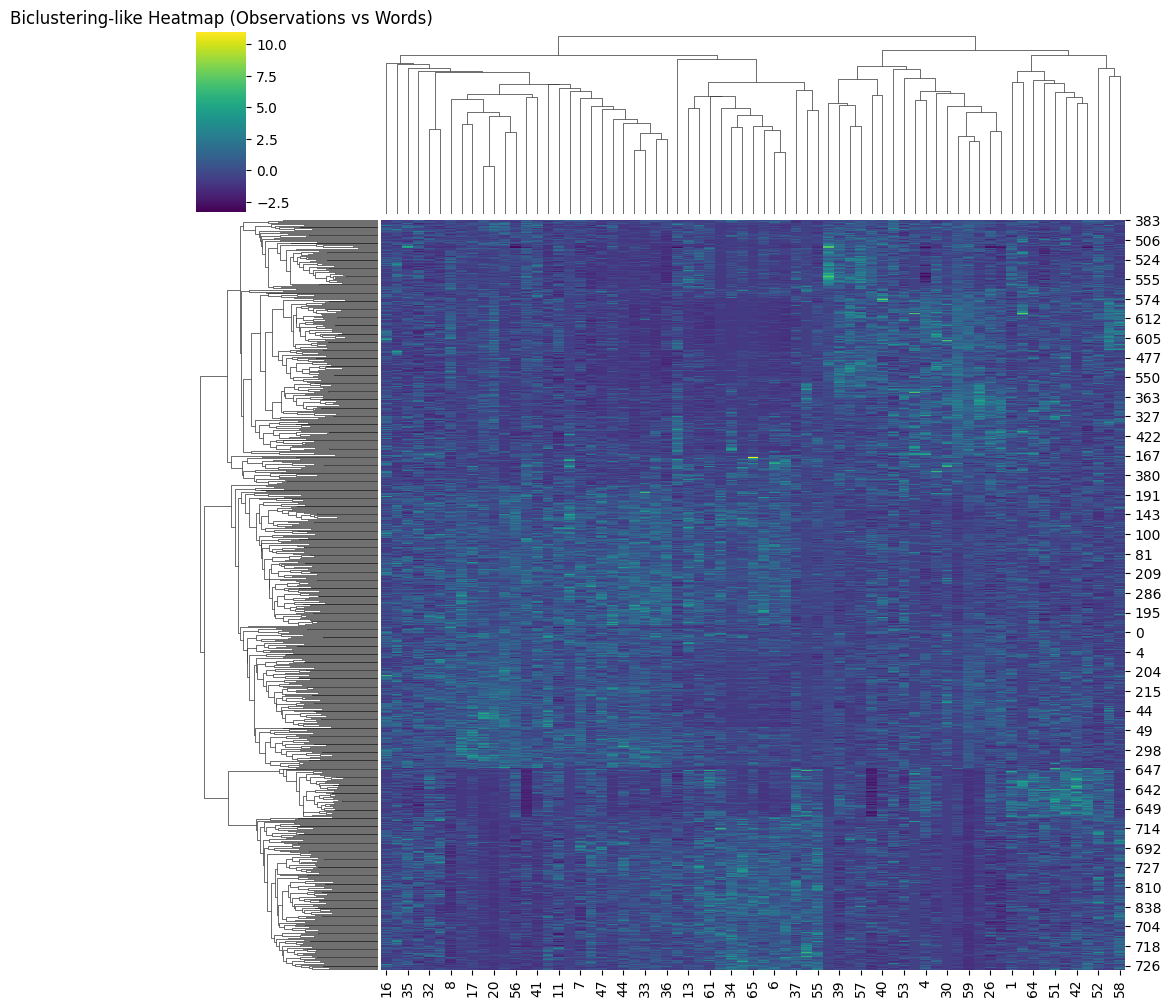

In [199]:
sns.clustermap(data_scaled, metric='cosine', method='average', cmap='viridis', figsize=(10, 10))
plt.title("Biclustering-like Heatmap (Observations vs Words)")
plt.show()

A hierarchical clustering heatmap of chapters and words was generated to explore local co-occurrence structure. While not a formal biclustering method, it provides a general overview of how both rows (observations) and columns (words) can be organized into groups based on similarity.

The clustermap revealed weak but visible diagonal and block patterns, suggesting that certain word groups are used more consistently by subsets of chapters.

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


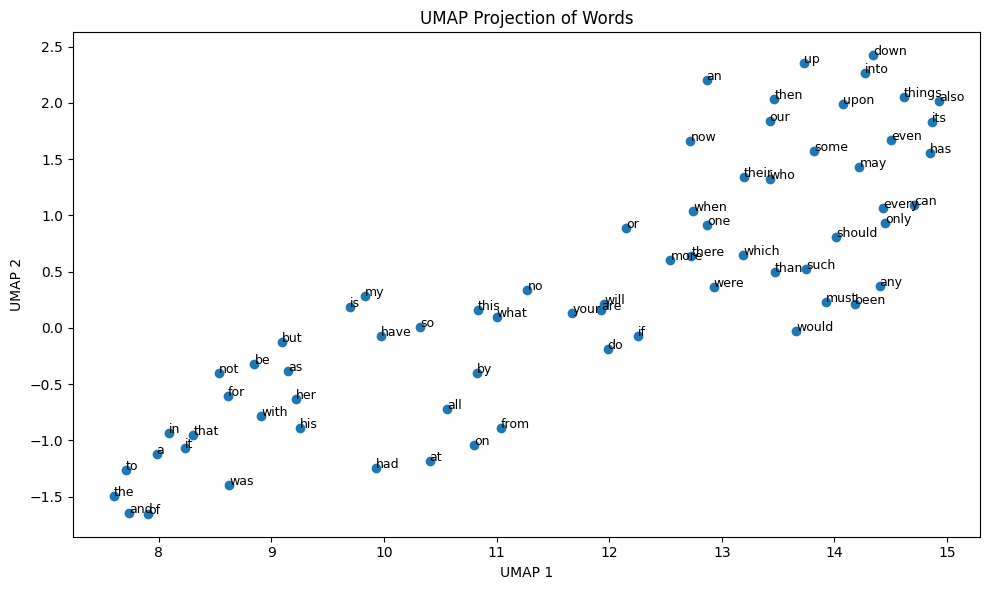

In [190]:
word_data = data.T
word_data_scaled = StandardScaler().fit_transform(word_data)

umap_word = umap.UMAP(n_neighbors=10, random_state=0)
word_embedding = umap_word.fit_transform(word_data_scaled)

plt.figure(figsize=(10,6))
plt.scatter(word_embedding[:, 0], word_embedding[:, 1])
for i, word in enumerate(word_data.index):
    plt.text(word_embedding[i, 0], word_embedding[i, 1], word, fontsize=9)
plt.title("UMAP Projection of Words")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


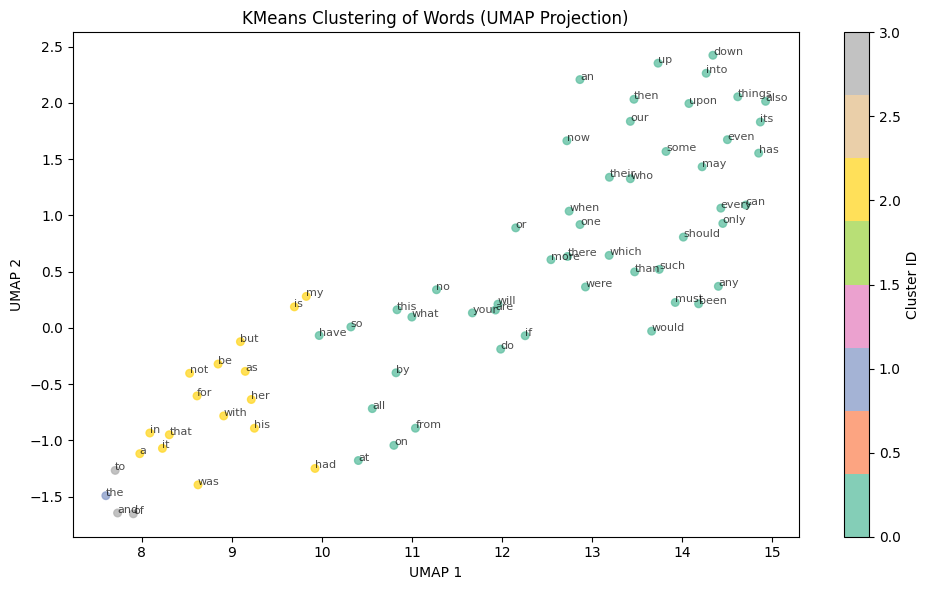

In [194]:
kmeans = KMeans(n_clusters=4, random_state=0)
word_labels = kmeans.fit_predict(word_data_scaled)

umap_model = umap.UMAP(n_neighbors=10, random_state=0)
word_embedding = umap_model.fit_transform(word_data_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(word_embedding[:, 0], word_embedding[:, 1],
                      c=word_labels, cmap='Set2', s=30, alpha=0.8)
for i, word in enumerate(word_data.index):
    plt.text(word_embedding[i, 0], word_embedding[i, 1], word, fontsize=8, alpha=0.7)
plt.title("KMeans Clustering of Words (UMAP Projection)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()

UMAP was used to project high-dimensional word frequency vectors into 2D space. This allows for visualization of local and global word similarity based on usage across chapters. Words with similar semantic or stylistic usage tended to cluster together. UMAP was especially effective in revealing smooth transitions and clusters of related words. Combined with UMAP projection, KMeans was applied to group words into stylistic or functional clusters. This method helps segment the vocabulary into groups like pronouns, modal verbs, function words, and so on—each potentially more prevalent in certain authors’ writing styles.

The UMAP plots revealed that function words like “the”, “was”, “to” formed dense, low-dimensional clusters, reflecting their similar usage across authors. More stylistically distinct or content-driven words appeared further apart.
The KMeans+UMAP clustering highlighted that stylistic word groups such as modal verbs (“must”, “would”, “should”), possessives (“my”, “his”), and prepositions grouped into coherent clusters—suggesting stylistic fingerprints.



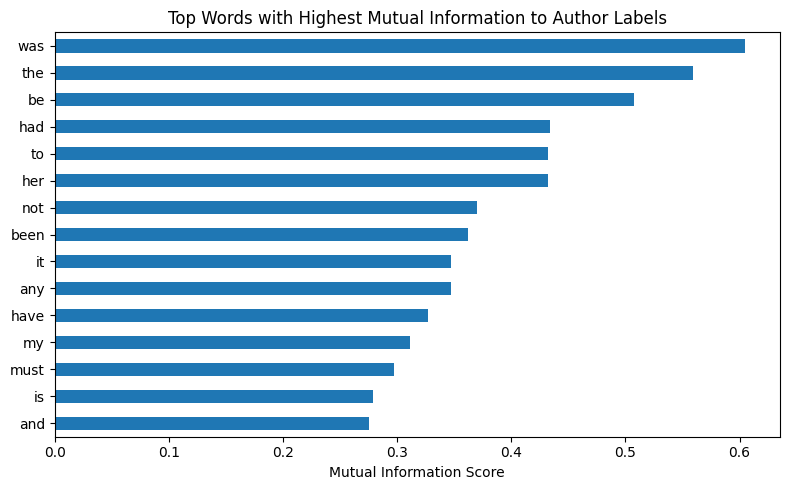

In [197]:
author_labels = LabelEncoder().fit_transform(data.index)

mi_scores = mutual_info_classif(data, author_labels, discrete_features=True)

mi_series = pd.Series(mi_scores, index=data.columns)
top_mi_words = mi_series.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_mi_words.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Words with Highest Mutual Information to Author Labels")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

Mutual information between word usage and known author labels was computed to identify the most discriminative words. This provides a statistical basis for interpreting which words carry the most information about authorship.

Mutual information results showed that high-frequency words like “was”, “the”, “had”, and “her” had the most discriminatory power in distinguishing between authors, even though they may seem semantically weak.


#### d) Validation. For this task, you should validate your unsupervised clustering results (e.g. not using the author labels) via the stability and generalizability principal. Use your approach to tune the number of clusters $K$. Does your method choose $K=4$ ? Which clustering techniques are the most stable or generalize the best? Interpret and reflect on your findings.

Best K: 4 with silhouette score: 0.1407


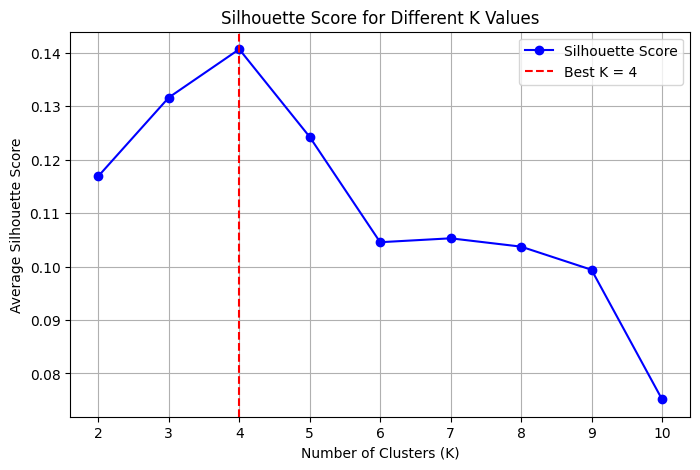

In [206]:
ave_silhouette = {}

K = 10
for i in range(2,K+1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(data_scaled)
    silhouette_vals = silhouette_samples(data_scaled, cluster_labels)
    ave_silhouette[i] = np.mean(silhouette_vals)

    
best_k = max(ave_silhouette, key=ave_silhouette.get)
print(f"Best K: {best_k} with silhouette score: {ave_silhouette[best_k]:.4f}")
    
plt.figure(figsize=(8, 5))
plt.plot(list(ave_silhouette.keys()), list(ave_silhouette.values()), marker='o', linestyle='-', color='b', label="Silhouette Score")
plt.axvline(best_k, color='r', linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.legend()
plt.grid(True)
plt.show()

The first plot uses the Silhouette Score to measure how well-separated the clusters are. The highest silhouette score indicates the most coherent clustering structure. Here, we observe the highest silhouette score (0.1407) at K = 4, clearly marking it as the best clustering solution. Silhouette analysis confirms that using four clusters produces groups that are most internally coherent and distinct from each other. As K increases beyond 4, the silhouette scores drop, indicating clusters become less distinct and more mixed.


In [142]:
data_scaled_df = pd.DataFrame(
    data_scaled,    
    columns=data.columns, 
    index=data.index   
)

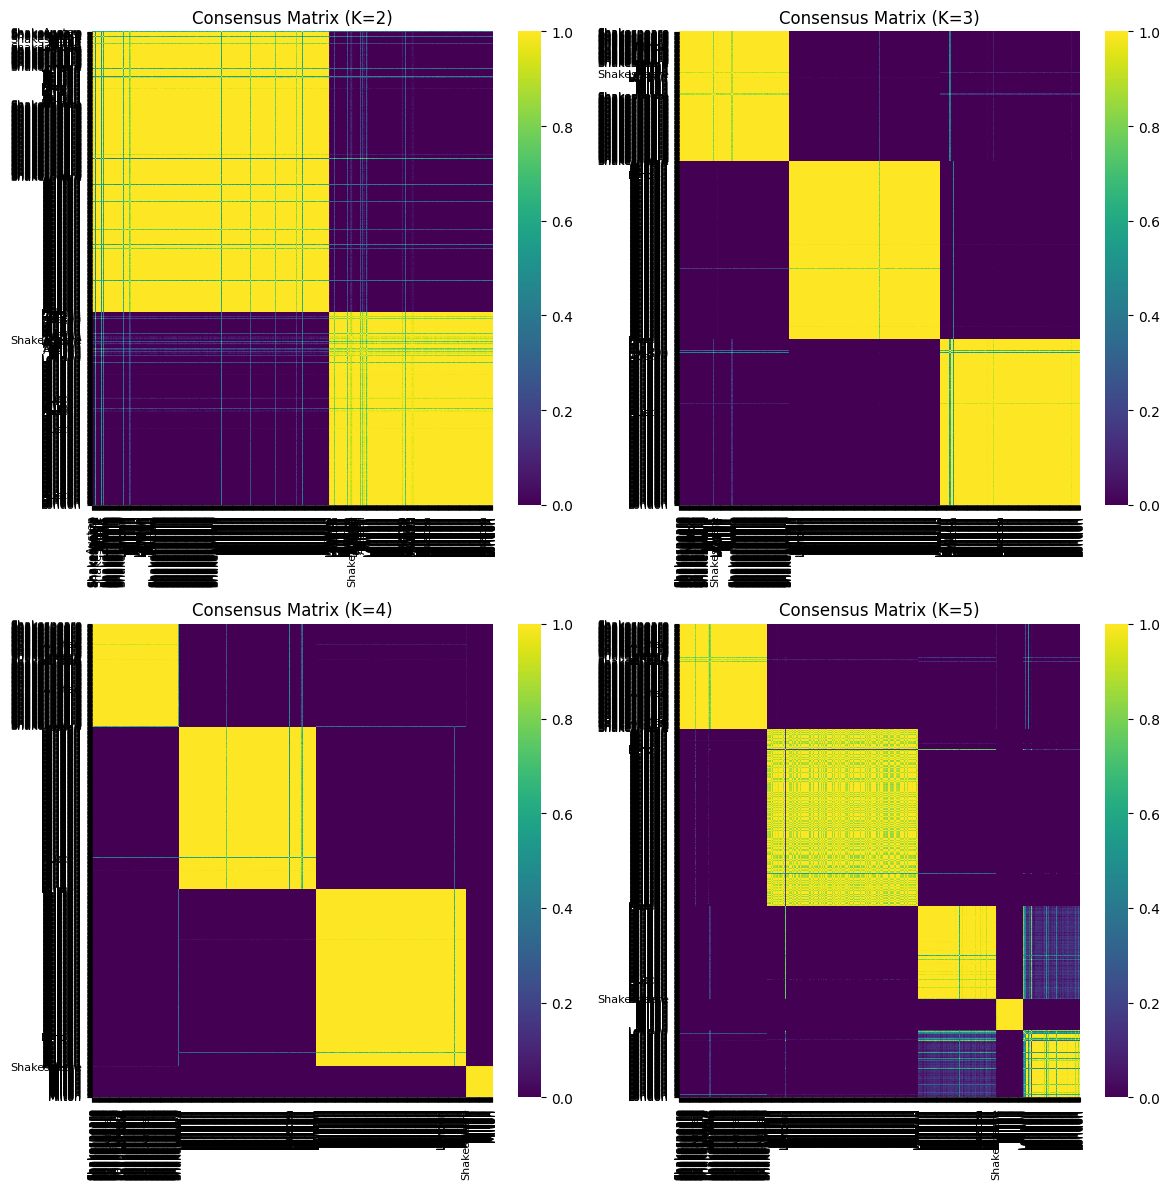

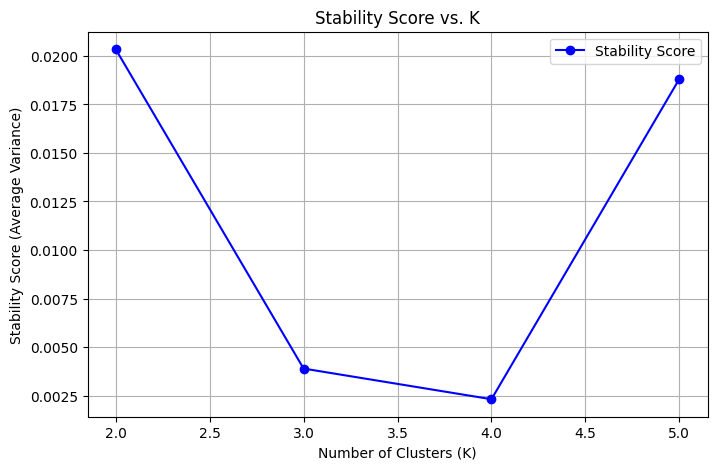

In [185]:
rng = np.random.default_rng(42)
iterations = 100
K_values = [2, 3, 4, 5]
stability_scores = []

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, K in enumerate(K_values):
    n_samples = data_scaled_df.shape[0]
    consensus_matrix = np.zeros((n_samples, n_samples))
    sampled_matrix = np.zeros((n_samples, n_samples))

    sample_names = data_scaled_df.index.to_numpy()

    for n in range(iterations):
        train_idx = rng.choice(n_samples, size=int(0.7 * n_samples), replace=False)
        X_train = data_scaled_df.iloc[train_idx].to_numpy()

        km = KMeans(n_clusters=K, random_state=n, n_init=10)
        cluster_labels = km.fit_predict(X_train)

        sampled_matrix[np.ix_(train_idx, train_idx)] += 1

        co_members = np.equal.outer(cluster_labels, cluster_labels)

        consensus_matrix[np.ix_(train_idx, train_idx)] += co_members

    with np.errstate(divide='ignore', invalid='ignore'):
        consensus_matrix = np.divide(consensus_matrix, sampled_matrix, where=(sampled_matrix != 0))
        consensus_matrix = np.nan_to_num(consensus_matrix)

    final_km = KMeans(n_clusters=K, random_state=42, n_init=10)
    final_clusters = final_km.fit_predict(data_scaled_df.to_numpy())

    order_idx = np.argsort(final_clusters)
    consensus_matrix = consensus_matrix[order_idx][:, order_idx]

    sns.heatmap(consensus_matrix, ax=axes[idx], cmap='viridis', xticklabels=sample_names[order_idx],yticklabels=sample_names[order_idx],)
    axes[idx].set_title(f'Consensus Matrix (K={K})')
    axes[idx].tick_params(axis='x', rotation=90, labelsize=8)  
    axes[idx].tick_params(axis='y', labelsize=8)  

    stability_score = 0
    n_pairs = 0

    for i in range(n_samples):
        for j in range(i + 1, n_samples):  # Only consider off-diagonal elements
            stability_score += consensus_matrix[i, j] * (1 - consensus_matrix[i, j])
            n_pairs += 1

    stability_score /= n_pairs  # Normalize by number of pairs
    stability_scores.append(stability_score)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_values, stability_scores, marker='o', linestyle='-', color='b', label="Stability Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Stability Score (Average Variance)")
plt.title("Stability Score vs. K")
plt.legend()
plt.grid()
plt.show()

The second set of plots displays the Consensus Matrix for different numbers of clusters (K = 2, 3, 4, 5). Each consensus matrix visually represents how frequently pairs of samples cluster together across multiple clustering runs. Clearer and sharper block structures (yellow blocks along the diagonal and purple elsewhere) represent more stable and distinct clusters.

At K=4, the consensus matrix shows clear and consistent block-diagonal structures. This suggests clusters are stable and reliably found across multiple runs. Conversely, at K=5, the clusters begin fragmenting into smaller sub-clusters (reflected by the small yellow fragments within larger purple blocks), indicating a less stable and potentially overfitted clustering structure.

The third plot quantifies this stability through a computed Stability Score, measuring the variance of consensus clustering. A lower stability score means clusters are highly stable (less variability). The stability score reaches its lowest point exactly at K=4, reinforcing the conclusion from the consensus matrices: clusters at K=4 are robust and generalize well across multiple clustering runs. For K \neq 4, the stability score rises sharply, signaling increased instability.



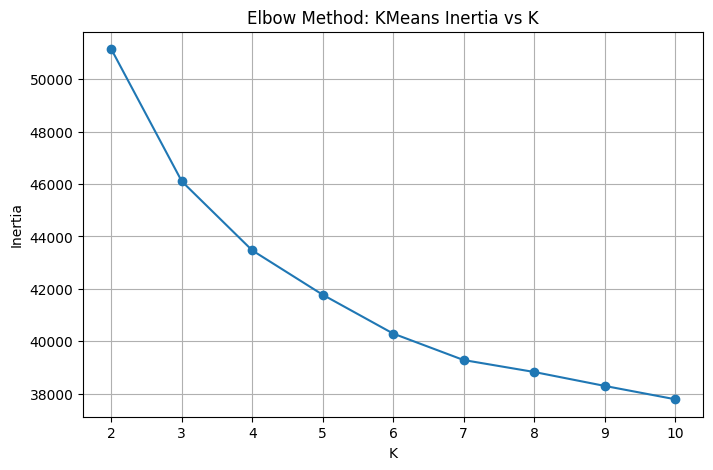

In [215]:
inertias = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(data_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertias, marker='o')
plt.title("Elbow Method: KMeans Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

The elbow method plot shows how the inertia (sum of squared distances within clusters) decreases as we increase K. Typically, we seek an “elbow” (a clear bend in the curve), marking diminishing returns from adding clusters. Here, the most significant bend occurs around K=4, indicating the optimal balance between cluster compactness and complexity. Beyond this point, adding additional clusters yields only minor improvements.


## In conclusion:

All three independent methods of analysis strongly support selecting K=4 as the optimal and most robust number of clusters for your data.

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:259: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:152: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:370: RuntimeWarning: invalid value encountered in add
  distances += XX
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:648: RuntimeWarning: overflow encountered in square
  lloyd_iter(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sk

Mean ARI for each clustering method (higher means more stable):
                 Method  Mean ARI
                 KMeans     0.987
       Gaussian Mixture     0.893
    Spectral Clustering     1.000
   Agglomerative (Ward)     1.000
Agglomerative (Average)     1.000


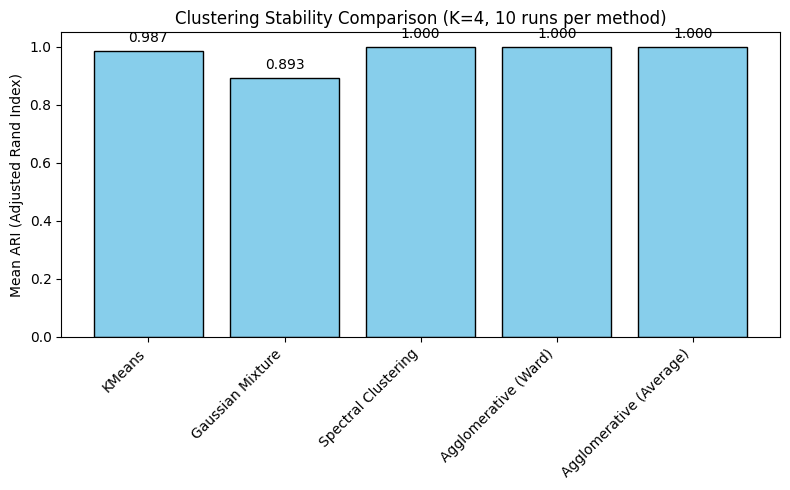

In [214]:
K = 4
runs = 10
seeds = list(range(runs))

mean_ari_results = {}

labels_runs = []
for seed in seeds:
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=seed)
    labels = kmeans.fit_predict(data)
    labels_runs.append(labels)

ari_values = []
for labels1, labels2 in combinations(labels_runs, 2):
    ari = adjusted_rand_score(labels1, labels2)
    ari_values.append(ari)
mean_ari_results["KMeans"] = np.mean(ari_values)

labels_runs = []
for seed in seeds:
    gmm = GaussianMixture(n_components=K, random_state=seed)
    gmm.fit(data)
    labels = gmm.predict(data)
    labels_runs.append(labels)

ari_values = []
for labels1, labels2 in combinations(labels_runs, 2):
    ari_values.append(adjusted_rand_score(labels1, labels2))
mean_ari_results["Gaussian Mixture"] = np.mean(ari_values)

labels_runs = []
for seed in seeds:
    spectral = SpectralClustering(n_clusters=K, random_state=seed, assign_labels='kmeans')
    labels = spectral.fit_predict(data)
    labels_runs.append(labels)

ari_values = []
for labels1, labels2 in combinations(labels_runs, 2):
    ari_values.append(adjusted_rand_score(labels1, labels2))
mean_ari_results["Spectral Clustering"] = np.mean(ari_values)

labels_runs = []
for i in range(runs):
    agg_ward = AgglomerativeClustering(n_clusters=K, linkage='ward')
    labels = agg_ward.fit_predict(data)
    labels_runs.append(labels)

ari_values = []
for labels1, labels2 in combinations(labels_runs, 2):
    ari_values.append(adjusted_rand_score(labels1, labels2))
mean_ari_results["Agglomerative (Ward)"] = np.mean(ari_values)

labels_runs = []
for i in range(runs):
    agg_avg = AgglomerativeClustering(n_clusters=K, affinity='euclidean', linkage='average')
    labels = agg_avg.fit_predict(data)
    labels_runs.append(labels)

ari_values = []
for labels1, labels2 in combinations(labels_runs, 2):
    ari_values.append(adjusted_rand_score(labels1, labels2))
mean_ari_results["Agglomerative (Average)"] = np.mean(ari_values)

results_df = pd.DataFrame({
    "Method": list(mean_ari_results.keys()),
    "Mean ARI": list(mean_ari_results.values())
})
results_df["Mean ARI"] = results_df["Mean ARI"].round(3)

print("Mean ARI for each clustering method (higher means more stable):")
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
methods = results_df["Method"]
mean_ari_values = results_df["Mean ARI"]

bars = plt.bar(methods, mean_ari_values, color='skyblue', edgecolor='black')
plt.ylabel("Mean ARI (Adjusted Rand Index)")
plt.title(f"Clustering Stability Comparison (K={K}, 10 runs per method)")
plt.ylim(0, 1.05)

for idx, val in enumerate(mean_ari_values):
    plt.text(idx, val + 0.02, f"{val:.3f}", ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Interpretation and Analysis:

The results indicate exceptionally high stability across clustering runs, particularly for Agglomerative (Ward and Average linkage) and Spectral Clustering, all yielding a mean ARI of exactly 1.0. Such perfect consistency is expected for Agglomerative methods due to their deterministic nature. Spectral Clustering also exhibited perfect stability, likely due to very clear and strong intrinsic group structures within the data. KMeans and Gaussian Mixture Models showed slightly lower but still very high stability scores (ARI ≥ 0.89), reflecting minor variability across different initializations. Overall, these results confirm that the dataset has strong, easily separable cluster structures, leading to highly reproducible clustering outcomes.